In [47]:
# some libraries we will need
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.constants as ac
#import cmasher as cm

import fb_models

In [41]:
Lw = 1e38*u.erg/u.s
Mdotw = 1e-4*u.Msun/u.yr
Vwind = np.sqrt(2*Lw/Mdotw).to(u.km/u.s)
pdotw = (Mdotw*Vwind).to(u.Msun*u.km/u.s/u.Myr)

nHbar = 100./(u.cm**3)
muH = 1.4
rho = ac.m_p*muH*nHbar

ad_bub = fb_models.AdiabaticWind(Lwind=Lw,rho0=rho,rfb=100*u.AU)

In [42]:
rlin = np.logspace(-1,2,10000)*u.pc
tlin = np.logspace(-2.5,-0.9,10)*u.Myr

Text(0, 0.5, '$T\\, [{\\rm K}]$')

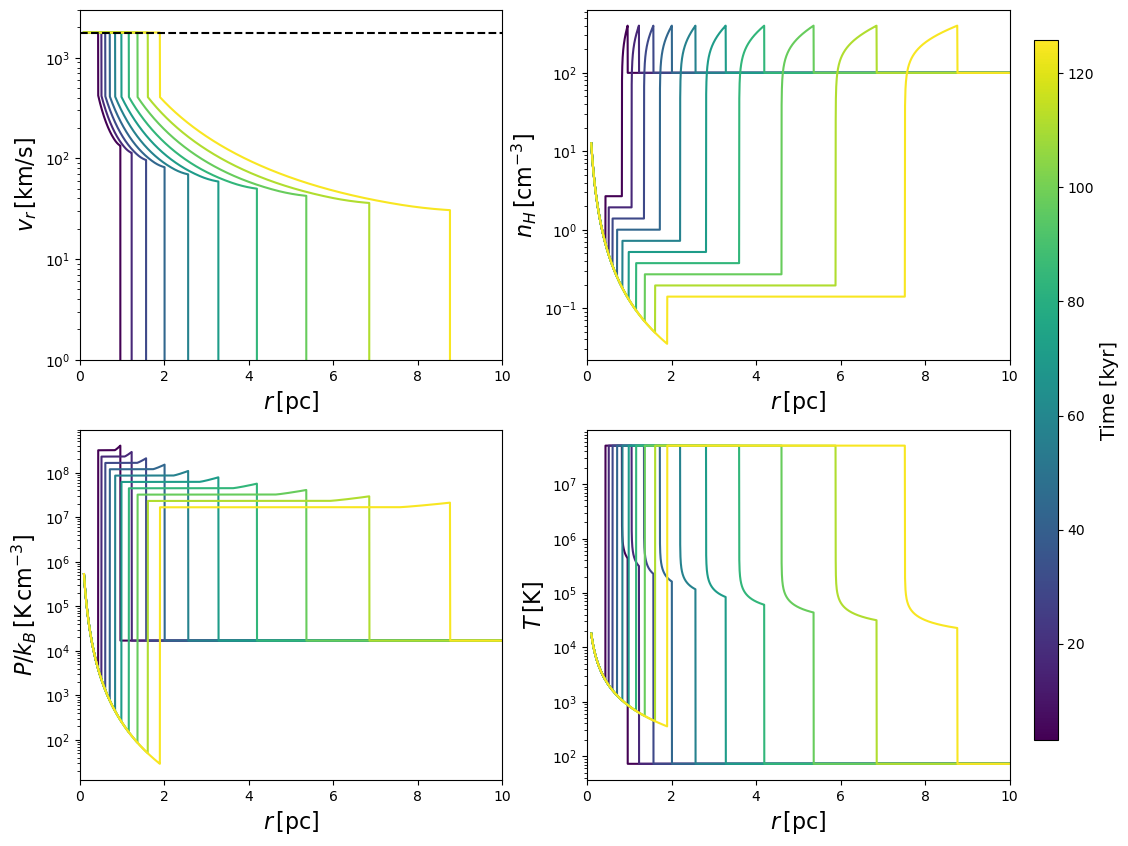

In [52]:
fig, axes = plt.subplots(2, 2, figsize=(12,10))
((ax1,ax2),(ax3,ax4)) = axes

cmap = plt.cm.viridis
norm = mpl.colors.Normalize(vmin=1e3*tlin.min().value, vmax=1e3*tlin.max().value)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = plt.colorbar(sm, cax=cbar_ax)
cbar.set_label("Time [kyr]", fontsize=14)

for (i,t) in enumerate(tlin):
    color = cmap((1.*i)/(len(tlin.value)-0.9))
    vel_prof = ad_bub.velocity_profile(rlin,t)
    dens_prof = ad_bub.density_profile(rlin,t)
    # actually given as P/k_B so this has units of K cm^-3
    press_prof = ad_bub.pressure_profile(rlin,t)
    (muH,mu) = (1.4,0.6)
    nH_prof = (dens_prof/(muH*ac.m_p)).to(1./u.cm**3)
    temp_prof = (press_prof*mu*ac.m_p/dens_prof).to(u.K)
    ax1.plot(rlin, vel_prof,c=color)
    ax2.plot(rlin, nH_prof,c=color)
    ax3.plot(rlin, press_prof,c=color)
    ax4.plot(rlin, temp_prof,c=color)

for ax in [ax1,ax2,ax3,ax4]:
    ax.set_xlim(0,10)
    ax.set_xlabel(r'$r\, [{\rm pc}]$',fontsize=16)
    ax.set_yscale("log")

ax1.axhline(y=Vwind.value,c='k',ls='--')
ax1.set_ylim(1,3e3)

ax1.set_ylabel(r'$v_r\, [{\rm km/s}]$',fontsize=16)
ax2.set_ylabel(r'$n_H\, [{\rm cm}^{-3}]$',fontsize=16)
ax3.set_ylabel(r'$P/k_B\, [{\rm K}\,{\rm cm}^{-3}]$',fontsize=16)
ax4.set_ylabel(r'$T\, [{\rm K}]$',fontsize=16)


In [65]:
tlin = np.linspace(0,0.15,1000)*u.Myr

/opt/anaconda3/envs/fb_sam/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


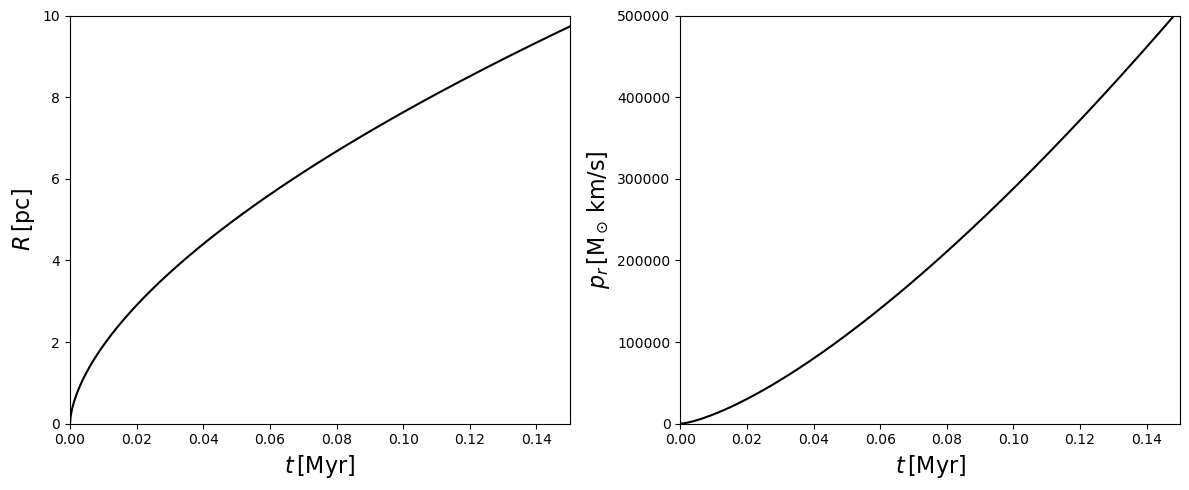

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
((ax1,ax2)) = axes

ax1.plot(tlin, ad_bub.radius(tlin),'k')
ax2.plot(tlin, ad_bub.momentum(tlin),'k')

for ax in [ax1,ax2]:
    ax.set_xlabel(r'$t\, [{\rm Myr}]$',fontsize=16)
    ax.set_xlim(0,0.15)

ax1.set_ylim(0,10)
ax2.set_ylim(0,5e5)
ax1.set_ylabel(r'$R\, [{\rm pc}]$',fontsize=16)
ax2.set_ylabel(r'$p_r\, [{\rm M}_\odot\,{\rm km/s}]$',fontsize=16)

plt.tight_layout()